# Customer Churn - Business-Focused EDA

This notebook explores the main business patterns behind customer churn.

The goal is to answer a few targeted questions:

- Which customer groups churn the most?
- Which product or contract choices are associated with churn?
- Are there clear patterns in tenure, pricing, and service usage?
- What hypotheses should be carried into the modeling stage?

This is a focused EDA, designed to support feature engineering and model validation rather than produce an exhaustive list of plots.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load raw data
df = pd.read_csv("../data/raw/Telco-Customer-Churn.csv")

# Minimal cleaning so this notebook can run independently
object_cols = df.select_dtypes(include="object").columns

df_eda = df.copy()

for col in object_cols:
    df_eda[col] = df_eda[col].astype(str).str.strip()

df_eda["TotalCharges"] = pd.to_numeric(df_eda["TotalCharges"], errors="coerce")
df_eda = df_eda.dropna(subset=["TotalCharges"]).copy()

print("EDA dataset shape:", df_eda.shape)
df_eda.head()

EDA dataset shape: (7032, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Churn overview

We start with a simple overview of the target variable.

This helps us quantify the churn rate and set the business context for the rest of the analysis. Since churners are the group the business wants to retain, understanding their proportion is the starting point for all later decisions.

Churn counts:
Churn
No     5163
Yes    1869
Name: count, dtype: int64

Churn percentage:
Churn
No     73.42
Yes    26.58
Name: proportion, dtype: float64


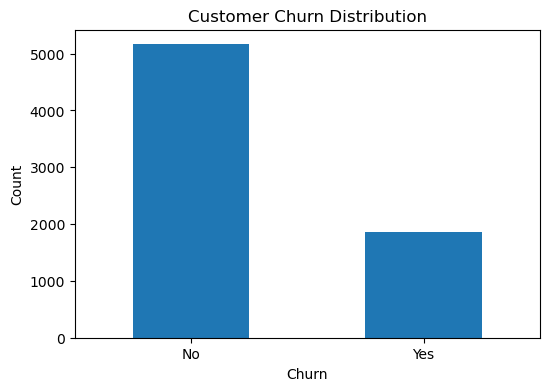

In [2]:
churn_counts = df_eda["Churn"].value_counts()
churn_pct = df_eda["Churn"].value_counts(normalize=True).mul(100).round(2)

print("Churn counts:")
print(churn_counts)

print("\nChurn percentage:")
print(churn_pct)

ax = churn_counts.plot(kind="bar", figsize=(6, 4), title="Customer Churn Distribution")
ax.set_xlabel("Churn")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=0)
plt.show()

The churn rate provides the baseline business risk in the dataset. Non-churners are the majority, but the churn segment is still large enough to be commercially important.

The next step is to understand whether churn is concentrated in specific customer groups, starting with contract type, tenure, and monthly charges.

## Churn by contract, tenure, and monthly charges

This section tests three practical business hypotheses:

- customers on shorter contracts are more likely to churn,
- newer customers are more likely to churn,
- and pricing may also be associated with churn risk.

These patterns are useful because they can later guide feature engineering and help interpret model behavior.

Churn rate by contract type (%):
Contract
Month-to-month    42.71
One year          11.28
Two year           2.85
Name: Yes, dtype: float64

Churn rate by tenure band (%):
tenure_band
0-12 months     47.68
13-24 months    28.71
25-48 months    20.39
49-72 months     9.51
Name: Yes, dtype: float64

Churn rate by monthly charge band (%):
monthly_charge_band
(18.249, 35.588]    11.32
(35.588, 70.35]     24.59
(70.35, 89.862]     37.55
(89.862, 118.75]    32.88
Name: Yes, dtype: float64


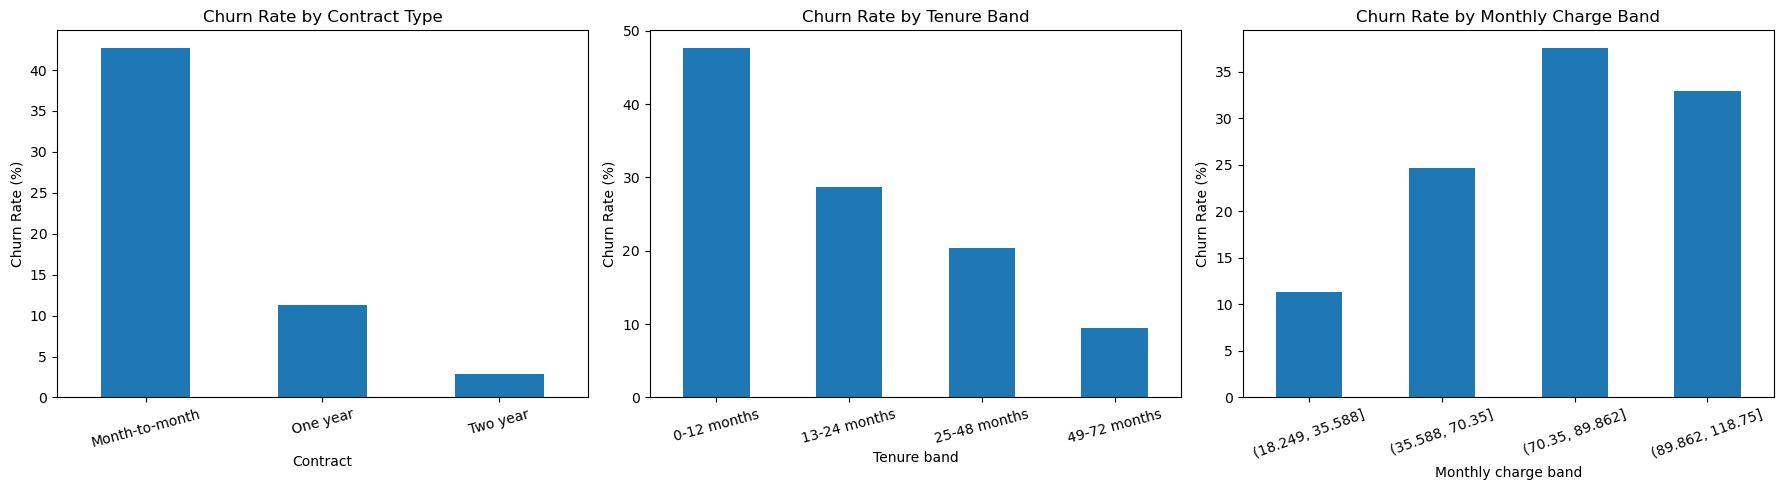

In [3]:
# --- Churn rate by contract type ---
contract_churn = (
    pd.crosstab(df_eda["Contract"], df_eda["Churn"], normalize="index")["Yes"]
    .sort_values(ascending=False)
    .mul(100)
    .round(2)
)

print("Churn rate by contract type (%):")
print(contract_churn)

# --- Create tenure bands ---
df_eda["tenure_band"] = pd.cut(
    df_eda["tenure"],
    bins=[-1, 12, 24, 48, 72],
    labels=["0-12 months", "13-24 months", "25-48 months", "49-72 months"]
)

tenure_churn = (
    pd.crosstab(df_eda["tenure_band"], df_eda["Churn"], normalize="index")["Yes"]
    .mul(100)
    .round(2)
)

print("\nChurn rate by tenure band (%):")
print(tenure_churn)

# --- Create monthly charge bands using quartiles ---
df_eda["monthly_charge_band"] = pd.qcut(
    df_eda["MonthlyCharges"],
    q=4,
    duplicates="drop"
)

charge_churn = (
    pd.crosstab(df_eda["monthly_charge_band"], df_eda["Churn"], normalize="index")["Yes"]
    .mul(100)
    .round(2)
)

print("\nChurn rate by monthly charge band (%):")
print(charge_churn)

# --- Plot all three ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

contract_churn.plot(kind="bar", ax=axes[0], title="Churn Rate by Contract Type")
axes[0].set_xlabel("Contract")
axes[0].set_ylabel("Churn Rate (%)")
axes[0].tick_params(axis="x", rotation=15)

tenure_churn.plot(kind="bar", ax=axes[1], title="Churn Rate by Tenure Band")
axes[1].set_xlabel("Tenure band")
axes[1].set_ylabel("Churn Rate (%)")
axes[1].tick_params(axis="x", rotation=15)

charge_churn.plot(kind="bar", ax=axes[2], title="Churn Rate by Monthly Charge Band")
axes[2].set_xlabel("Monthly charge band")
axes[2].set_ylabel("Churn Rate (%)")
axes[2].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

Contract type and tenure appear to be the clearest churn drivers so far. Customers with month-to-month contracts and customers in their first year show substantially higher churn rates, which suggests that customer commitment and lifecycle stage are central to the churn problem.

Monthly charges also appear relevant, but the relationship is less monotonic. This indicates that price alone may not explain churn and may interact with other customer characteristics such as contract structure or service mix.

## Churn by payment behavior and service usage

In this section, we test whether churn is associated with how customers pay and what services they use.

This helps answer two practical questions:
- Are some payment behaviors linked to higher churn?
- Do some service types or service bundles correspond to more stable customers?

Churn rate by payment method (%):
PaymentMethod
Electronic check             45.29
Mailed check                 19.20
Bank transfer (automatic)    16.73
Credit card (automatic)      15.25
Name: Yes, dtype: float64

Churn rate by internet service (%):
InternetService
Fiber optic    41.89
DSL            19.00
No              7.43
Name: Yes, dtype: float64

Churn rate by service count (%):
service_count
0    43.75
1    21.15
2    32.88
3    36.48
4    31.38
5    25.61
6    22.55
7    12.41
8     5.29
Name: Yes, dtype: float64


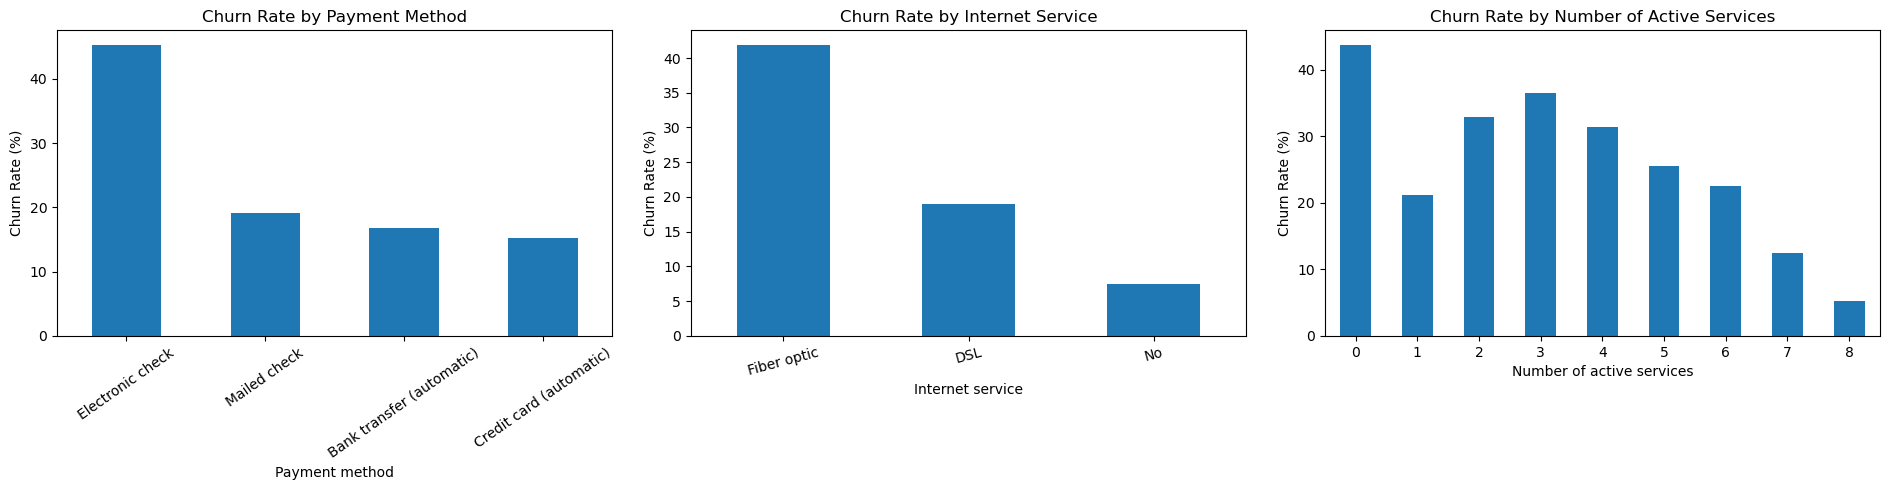

In [7]:
# --- Churn rate by payment method ---
payment_churn = (
    pd.crosstab(df_eda["PaymentMethod"], df_eda["Churn"], normalize="index")["Yes"]
    .sort_values(ascending=False)
    .mul(100)
    .round(2)
)

print("Churn rate by payment method (%):")
print(payment_churn)

# --- Churn rate by internet service ---
internet_churn = (
    pd.crosstab(df_eda["InternetService"], df_eda["Churn"], normalize="index")["Yes"]
    .sort_values(ascending=False)
    .mul(100)
    .round(2)
)

print("\nChurn rate by internet service (%):")
print(internet_churn)

# --- Build service count feature ---
service_cols = [
    "PhoneService",
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

def is_active_service(x):
    x = str(x).strip()
    return int(x == "Yes")

df_eda["service_count"] = df_eda[service_cols].map(is_active_service).sum(axis=1)

service_count_churn = (
    pd.crosstab(df_eda["service_count"], df_eda["Churn"], normalize="index")["Yes"]
    .mul(100)
    .round(2)
)

print("\nChurn rate by service count (%):")
print(service_count_churn)

# --- Plot all three ---
fig, axes = plt.subplots(1, 3, figsize=(19, 5))

payment_churn.plot(kind="bar", ax=axes[0], title="Churn Rate by Payment Method")
axes[0].set_xlabel("Payment method")
axes[0].set_ylabel("Churn Rate (%)")
axes[0].tick_params(axis="x", rotation=35)

internet_churn.plot(kind="bar", ax=axes[1], title="Churn Rate by Internet Service")
axes[1].set_xlabel("Internet service")
axes[1].set_ylabel("Churn Rate (%)")
axes[1].tick_params(axis="x", rotation=15)

service_count_churn.plot(kind="bar", ax=axes[2], title="Churn Rate by Number of Active Services")
axes[2].set_xlabel("Number of active services")
axes[2].set_ylabel("Churn Rate (%)")
axes[2].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

Payment behavior and service mix add important business context to the churn problem.

Customers paying by electronic check show substantially higher churn than customers using automatic payment methods. Internet service also appears highly relevant, with fiber optic customers showing much higher churn than DSL customers or customers without internet service.

The service count pattern suggests that more deeply engaged customers tend to be more stable, although this relationship is not perfectly linear and likely interacts with contract type, tenure, and internet service.

## Key takeaways for modeling

This EDA highlights a few strong hypotheses that should carry into the modeling stage:

1. **Customer commitment matters.**  
   Contract type and tenure are among the strongest churn signals, suggesting that lifecycle stage and commitment level are central to the problem.

2. **Pricing and service type matter, but likely through interactions.**  
   Monthly charges and internet service both show clear differences in churn, especially for fiber optic customers.

3. **Payment behavior is highly informative.**  
   Electronic check customers churn much more than customers using automatic payment methods.

4. **Customer engagement may reduce churn.**  
   Customers with more active services tend to churn less, although this relationship is not perfectly monotonic and should be treated carefully.

These findings suggest that the next modeling notebook should not only compare algorithms, but also consider targeted feature engineering based on tenure, contract structure, payment behavior, and service usage.

## Numeric relationships, correlation, and outlier checks

This section strengthens the exploratory analysis by focusing on the numeric variables in the dataset.

The goals are:
- to compare the numeric distributions of churners vs non-churners,
- to understand the main numeric relationships,
- and to identify extreme values that may affect modeling.

Outliers are not automatically treated as errors in this project. The objective is first to understand whether they appear to be valid business observations or suspicious records.

In [9]:
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen"]

print("Numeric summary by churn group:")
print(df_eda.groupby("Churn")[numeric_cols].agg(["mean", "median"]).round(2))

Numeric summary by churn group:
      tenure        MonthlyCharges        TotalCharges          SeniorCitizen  \
        mean median           mean median         mean   median          mean   
Churn                                                                           
No     37.65   38.0          61.31  64.45      2555.34  1683.60          0.13   
Yes    17.98   10.0          74.44  79.65      1531.80   703.55          0.25   

              
      median  
Churn         
No       0.0  
Yes      0.0  


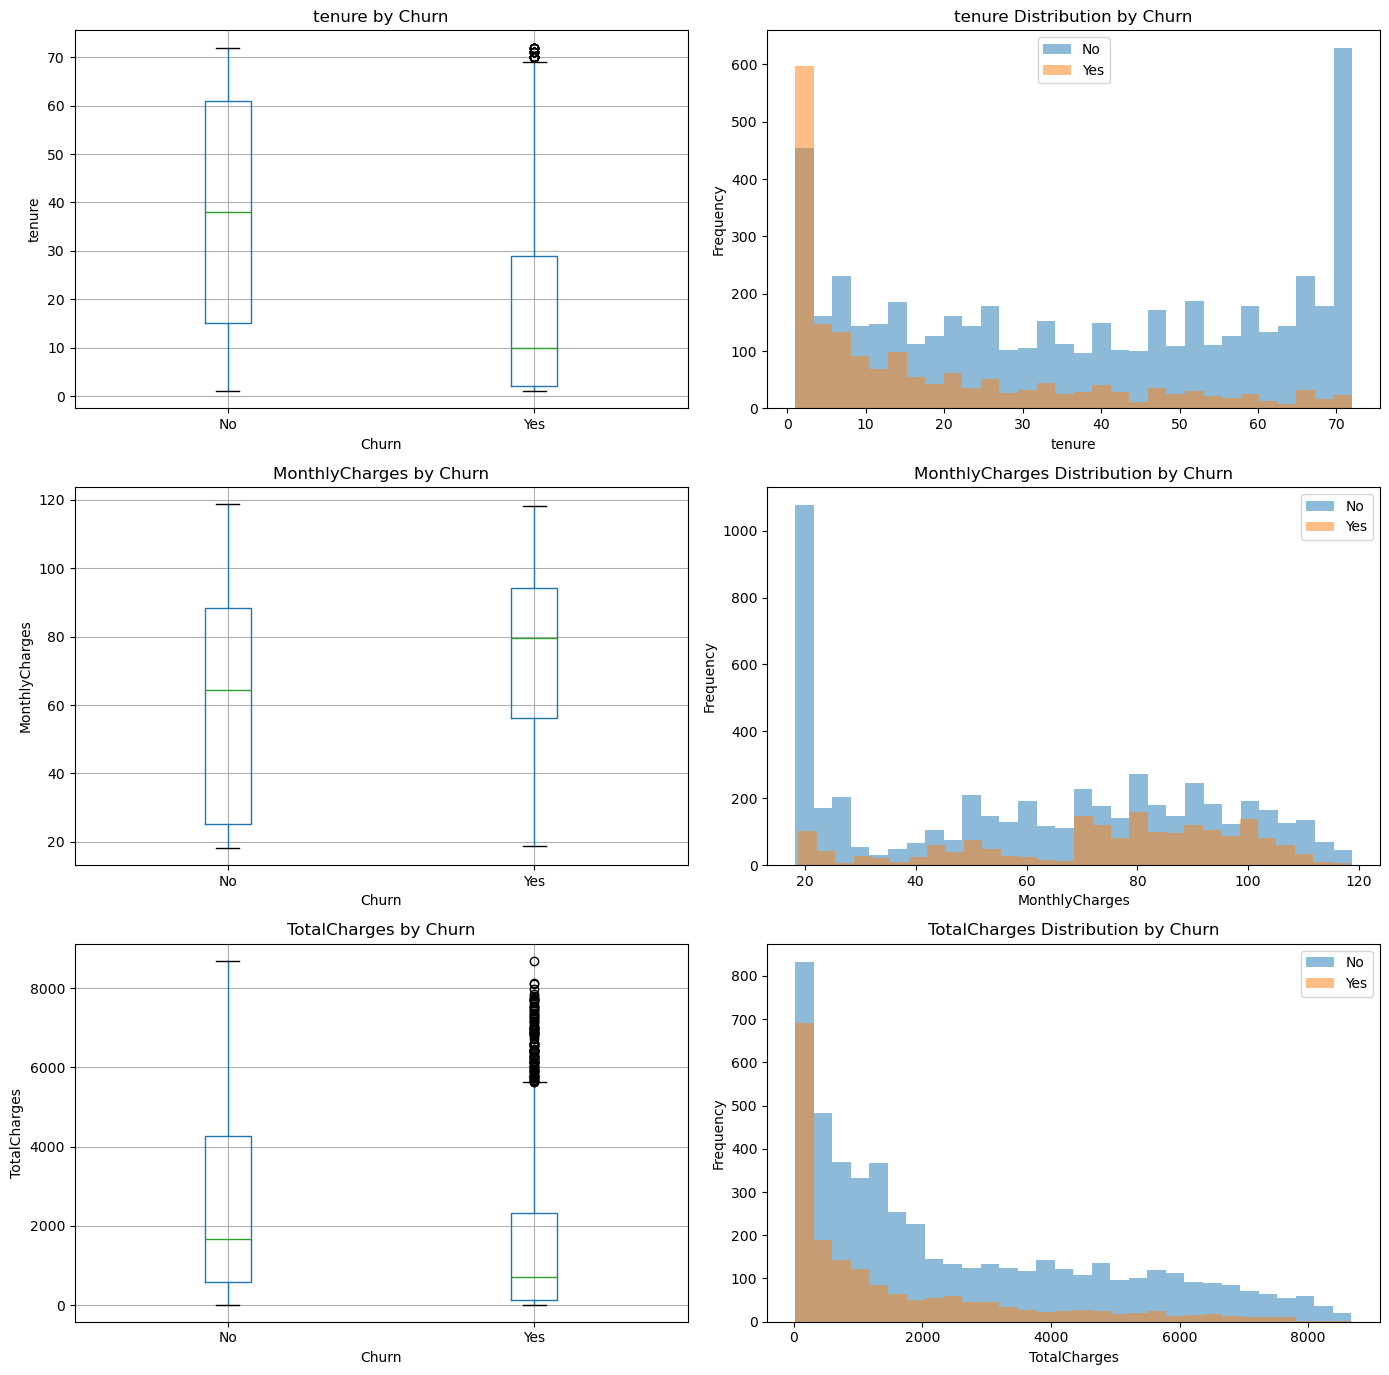

In [10]:
fig, axes = plt.subplots(3, 2, figsize=(14, 14))

plot_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

for i, col in enumerate(plot_cols):
    # Boxplot by churn
    df_eda.boxplot(column=col, by="Churn", ax=axes[i, 0])
    axes[i, 0].set_title(f"{col} by Churn")
    axes[i, 0].set_xlabel("Churn")
    axes[i, 0].set_ylabel(col)

    # Histogram by churn
    for churn_value in ["No", "Yes"]:
        df_eda[df_eda["Churn"] == churn_value][col].plot(
            kind="hist",
            bins=30,
            alpha=0.5,
            ax=axes[i, 1],
            label=churn_value
        )
    axes[i, 1].set_title(f"{col} Distribution by Churn")
    axes[i, 1].set_xlabel(col)
    axes[i, 1].set_ylabel("Frequency")
    axes[i, 1].legend()

plt.suptitle("")
plt.tight_layout()
plt.show()

Correlation matrix:
                tenure  MonthlyCharges  TotalCharges  SeniorCitizen
tenure           1.000           0.247         0.826          0.016
MonthlyCharges   0.247           1.000         0.651          0.220
TotalCharges     0.826           0.651         1.000          0.102
SeniorCitizen    0.016           0.220         0.102          1.000


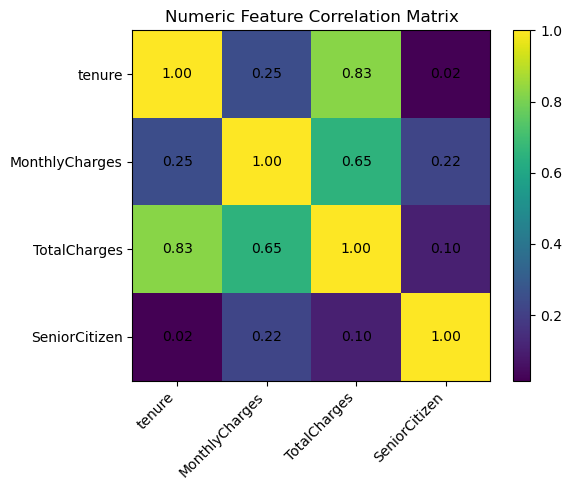

In [11]:
corr = df_eda[["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen"]].corr()

print("Correlation matrix:")
print(corr.round(3))

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, aspect="auto")

ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr.index)))
ax.set_yticklabels(corr.index)
ax.set_title("Numeric Feature Correlation Matrix")

for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center")

plt.colorbar(im)
plt.tight_layout()
plt.show()

In [12]:
def iqr_outlier_summary(df, cols):
    rows = []

    for col in cols:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        outlier_mask = (df[col] < lower) | (df[col] > upper)
        outlier_count = outlier_mask.sum()
        outlier_pct = round(outlier_count / len(df) * 100, 2)

        rows.append({
            "feature": col,
            "q1": round(q1, 2),
            "q3": round(q3, 2),
            "iqr": round(iqr, 2),
            "lower_bound": round(lower, 2),
            "upper_bound": round(upper, 2),
            "outlier_count": int(outlier_count),
            "outlier_pct": outlier_pct
        })

    return pd.DataFrame(rows)

outlier_summary = iqr_outlier_summary(df_eda, ["tenure", "MonthlyCharges", "TotalCharges"])
outlier_summary

,feature,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_pct
0,tenure,9.00,55.00,46.00,-60.00,124.00,0,0.0
1,MonthlyCharges,35.59,89.86,54.28,-45.82,171.27,0,0.0
2,TotalCharges,401.45,3794.74,3393.29,-4688.48,8884.67,0,0.0


## Multivariate outlier check in numeric feature space

The previous IQR analysis was univariate, meaning it assessed each numeric variable separately. That is useful, but it can miss observations that are not extreme in any single variable and are still unusual when several variables are considered together.

To address that limitation, this section uses a robust multivariate distance measure based on the numeric feature space:
- `tenure`
- `MonthlyCharges`
- `TotalCharges`
- `SeniorCitizen`

This is a diagnostic step. The goal is not to remove records automatically, but to identify potentially unusual customer profiles and assess whether they appear implausible or simply rare.

In [15]:
from sklearn.covariance import MinCovDet
from scipy.stats import chi2

numeric_space = df_eda[["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen"]].copy()

# Robust covariance estimator
mcd = MinCovDet(random_state=42)
mcd.fit(numeric_space)

# Squared robust Mahalanobis distances
mahal_sq = mcd.mahalanobis(numeric_space)

# Chi-square cutoff with df equal to the number of numeric variables
df_num = numeric_space.shape[1]
cutoff_975 = chi2.ppf(0.975, df=df_num)
cutoff_99 = chi2.ppf(0.99, df=df_num)

df_eda["mahalanobis_sq"] = mahal_sq
df_eda["multivar_outlier_975"] = df_eda["mahalanobis_sq"] > cutoff_975
df_eda["multivar_outlier_99"] = df_eda["mahalanobis_sq"] > cutoff_99

print("97.5% cutoff:", round(cutoff_975, 3))
print("99.0% cutoff :", round(cutoff_99, 3))

print("\nFlagged observations:")
print("Outliers at 97.5% cutoff:", int(df_eda["multivar_outlier_975"].sum()))
print("Outliers at 99.0% cutoff :", int(df_eda["multivar_outlier_99"].sum()))

df_eda[["mahalanobis_sq", "multivar_outlier_975", "multivar_outlier_99"]].head()

97.5% cutoff: 11.143
99.0% cutoff : 13.277

Flagged observations:
Outliers at 97.5% cutoff: 2309
Outliers at 99.0% cutoff : 2161


,mahalanobis_sq,multivar_outlier_975,multivar_outlier_99
0,3.971350,False,False
1,0.977208,False,False
2,1.322397,False,False
3,6.167208,False,False
4,1.980722,False,False


In [16]:
multivar_summary = pd.DataFrame({
    "cutoff": ["97.5%", "99.0%"],
    "threshold": [cutoff_975, cutoff_99],
    "flagged_count": [
        int(df_eda["multivar_outlier_975"].sum()),
        int(df_eda["multivar_outlier_99"].sum())
    ],
    "flagged_pct": [
        round(df_eda["multivar_outlier_975"].mean() * 100, 2),
        round(df_eda["multivar_outlier_99"].mean() * 100, 2)
    ]
})

multivar_summary

,cutoff,threshold,flagged_count,flagged_pct
0,97.5%,11.143287,2309,32.84
1,99.0%,13.276704,2161,30.73


In [18]:
# Inspect the most extreme observations
extreme_multivar = (
    df_eda.sort_values("mahalanobis_sq", ascending=False)
    [["customerID", "tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen",
      "Contract", "InternetService", "PaymentMethod", "Churn", "mahalanobis_sq"]]
    .head(15)
)

extreme_multivar

,customerID,tenure,MonthlyCharges,TotalCharges,SeniorCitizen,Contract,InternetService,PaymentMethod,Churn,mahalanobis_sq
4229,5451-YHYPW,72,115.75,8443.70,1,Two year,Fiber optic,Credit card (automatic),No,73.366435
4155,6904-JLBGY,72,117.35,8436.25,1,Two year,Fiber optic,Credit card (automatic),No,72.138847
464,1480-BKXGA,72,116.05,8404.90,1,Two year,Fiber optic,Bank transfer (automatic),No,71.856637
526,8606-CIQUL,72,115.75,8399.15,1,Two year,Fiber optic,Credit card (automatic),No,71.842715
5742,5135-GRQJV,72,114.50,8331.95,1,Two year,Fiber optic,Mailed check,No,70.331833
1135,1779-PWPMG,72,114.65,8333.95,1,Two year,Fiber optic,Bank transfer (automatic),No,70.308926
1280,2388-LAESQ,72,114.85,8317.95,1,Two year,Fiber optic,Bank transfer (automatic),No,69.657442
2689,8628-MFKAX,72,116.75,8277.05,1,Two year,Fiber optic,Credit card (automatic),No,67.217294
4768,3996-ZNWYK,71,19.80,1388.45,1,Two year,No,Credit card (automatic),No,66.502494
746,6919-ELBGL,72,114.95,8196.40,1,Two year,Fiber optic,Bank transfer (automatic),No,65.660002


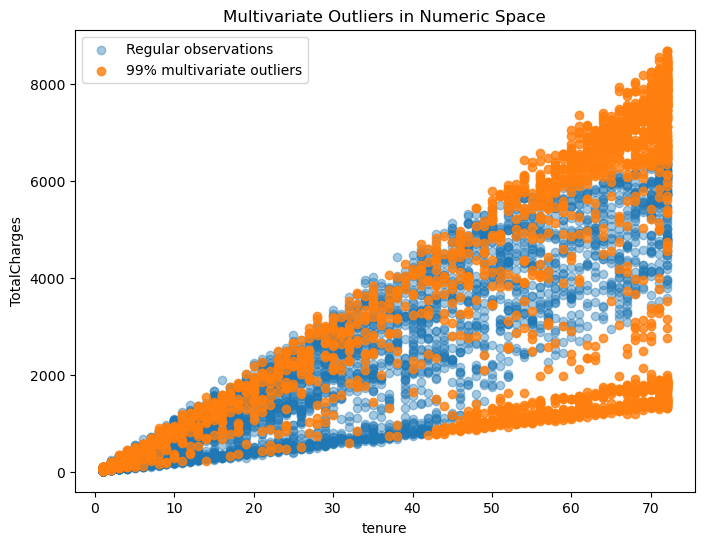

In [19]:
# Visualize multivariate outliers in a business-relevant numeric view
fig, ax = plt.subplots(figsize=(8, 6))

normal_mask = ~df_eda["multivar_outlier_99"]
outlier_mask = df_eda["multivar_outlier_99"]

ax.scatter(
    df_eda.loc[normal_mask, "tenure"],
    df_eda.loc[normal_mask, "TotalCharges"],
    alpha=0.4,
    label="Regular observations"
)

ax.scatter(
    df_eda.loc[outlier_mask, "tenure"],
    df_eda.loc[outlier_mask, "TotalCharges"],
    alpha=0.8,
    label="99% multivariate outliers"
)

ax.set_title("Multivariate Outliers in Numeric Space")
ax.set_xlabel("tenure")
ax.set_ylabel("TotalCharges")
ax.legend()
plt.show()

### Interpretation of the multivariate outlier diagnostic

The robust Mahalanobis analysis flags a surprisingly large share of observations, even under the stricter 99% cutoff. This suggests that the method is not well aligned with the geometry of the numeric feature space in this dataset.

The likely reason is structural rather than pathological: `TotalCharges`, `tenure`, and `MonthlyCharges` follow strong business constraints and do not form a roughly elliptical cloud. As a result, many valid customer profiles are treated as multivariate extremes.

A review of the most extreme records does not suggest obvious data corruption. Most appear to be plausible high-value or otherwise unusual customer profiles. For that reason, this diagnostic is treated as a methodological caution rather than a basis for removing observations.

## Final EDA conclusions

This exploratory analysis shows that churn is not random and is strongly associated with identifiable customer patterns.

The main findings are:

- **Customer commitment is a central churn driver.**  
  Month-to-month customers churn far more than one-year and two-year customers.

- **Customer lifecycle matters.**  
  Churn is highest among newer customers and declines steadily as tenure increases.

- **Pricing is relevant, but not in isolation.**  
  Customers who churn tend to have higher monthly charges, although the relationship is likely interacting with contract type and service mix.

- **Payment behavior is highly informative.**  
  Customers using electronic check show much higher churn than customers using automatic payment methods.

- **Internet service and service engagement matter.**  
  Fiber optic customers show substantially higher churn, and customers with deeper service usage tend to be more stable overall, although that pattern is not perfectly monotonic.

The numeric analysis reinforces this picture. Compared with non-churners, churners tend to have:
- much lower tenure,
- higher monthly charges,
- and lower total accumulated charges.

The correlation structure is also business-consistent, especially the strong relationship between `tenure` and `TotalCharges`.

## Outlier analysis conclusion

Both univariate and multivariate outlier checks were explored in this notebook.

The univariate IQR analysis did not reveal strong evidence of invalid numeric extremes. A multivariate robust Mahalanobis diagnostic was also tested, but it flagged a surprisingly large share of observations. This suggests that the method is not well aligned with the geometry of the numeric feature space in this dataset.

A review of the most extreme records indicates that they are generally plausible customer profiles rather than obvious data errors. For that reason, no observations are removed based on outlier diagnostics at this stage.

The conclusion is that unusual values in this dataset should be treated as potentially informative business cases, not automatically as bad data.